<a href="https://colab.research.google.com/github/ValeriiSlynko/IT-STEP-Practice/blob/master/Practice_Pandas/HmWrk3_Pandas(Pipeline%20%26%20Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# підвантажуємо бібліотеки для роботи
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# завантажуємо dataset
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

ІНФОРМАЦІЯ ПРО ДАНІ

**Posted On** -- Дата публікації

**BHK** -- Кількість спалень, вітальня та кухня.

**Rent** -- Вартість оренди будинку чи квартири.

**Size** -- Розмір будинку чи квартири у квадратних футах.

**Floor** -- Поверх, на якому розташоване житло, та загальна кількість поверхів у будинку (наприклад: перший із 2, третій із 5 тощо).

**Area Type** -- Розрахунок площі житла (загальна площа, корисна площа або площа забудови).

**Area Locality** -- Locality of the Houses/Apartments/Flats.

**City** -- Місто, де розташоване житло.

**Furnishing Status** -- Стан меблювання (повністю мебльоване, частково мебльоване або без меблів).

**Tenant Preferred** -- Тип орендаря, якому надає перевагу власник або агент.

**Bathroom** -- Кількість ванних кімнат.

**Point of Contact** -- До кого звертатися за додатковою інформацією щодо житла.

# Завдання 1 Очистіть дані від викидів/ Отримайте ознаки та цільову змінну(X, y) / Розділіть дані на тренувальні та тестові

*Очищаємо дані від икидів*

In [3]:
# визначаємо кількість рядків та стовпчиків
rows, columns = df.shape
print(f"Таблиця має '{rows}' рядків та '{columns}' стовпчиків/колнок")

Таблиця має '4746' рядків та '12' стовпчиків/колнок


In [4]:
# отримуємо назви всіх стовпчиків та типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 482.0+ KB


In [5]:
# дивимось кількість пропусків у стовпчиків
df.isna().sum()

,0
Posted On,367
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374


In [6]:
# показуємо табличний dataset з першими 20 рядками
df.head(20)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
5,2022-04-29,2.0,7000.0,600.0,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
6,2022-06-21,2.0,10000.0,700.0,Ground out of 4,Super Area,Malancha,Kolkata,Unfurnished,Bachelors,NaN,Contact Agent
7,2022-06-21,1.0,5000.0,250.0,1 out of 2,Super Area,Malancha,NaN,Unfurnished,Bachelors,1.0,Contact Agent
8,2022-06-07,2.0,26000.0,800.0,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2.0,Contact Agent
9,2022-06-20,2.0,NaN,1000.0,1 out of 3,Carpet Area,Natunhat,Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Owner


Гістограми для всіх числових стовпчиків

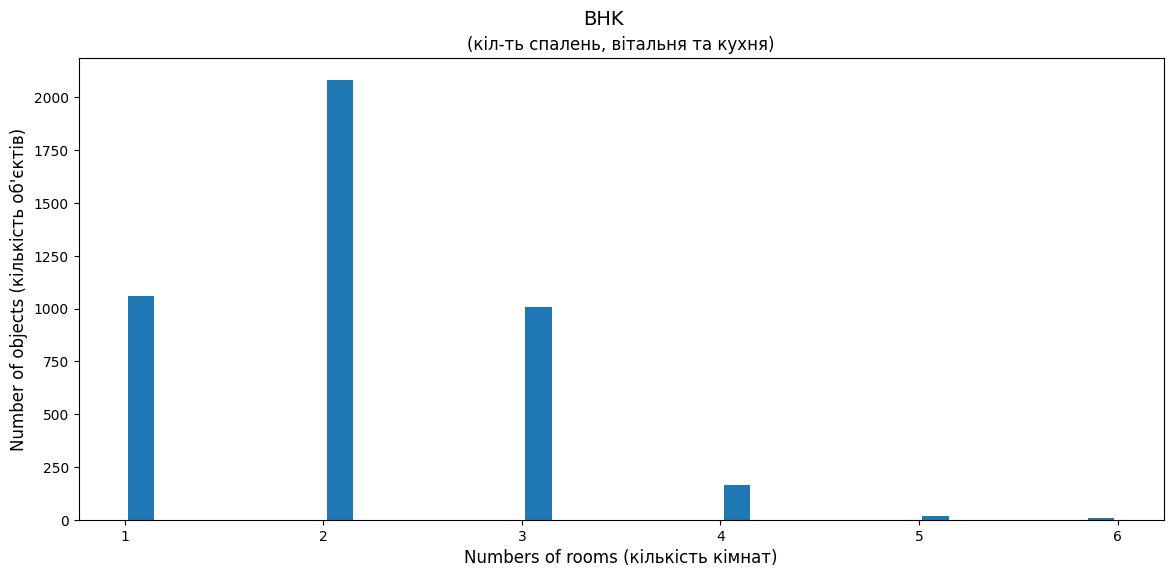

In [7]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = df['BHK'].plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('BHK', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(кіл-ть спалень, вітальня та кухня)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Numbers of rooms (кількість кімнат)', fontsize=12) # Підпис горизонтальної осі X (значення BHK / кількість кімнат)
ax.set_ylabel("Number of objects (кількість об'єктів)", fontsize=12) # Підпис вертикальної осі Y (кількість квартир у датасеті)
plt.show() # Виводимо остаточно сформований графік на екран.

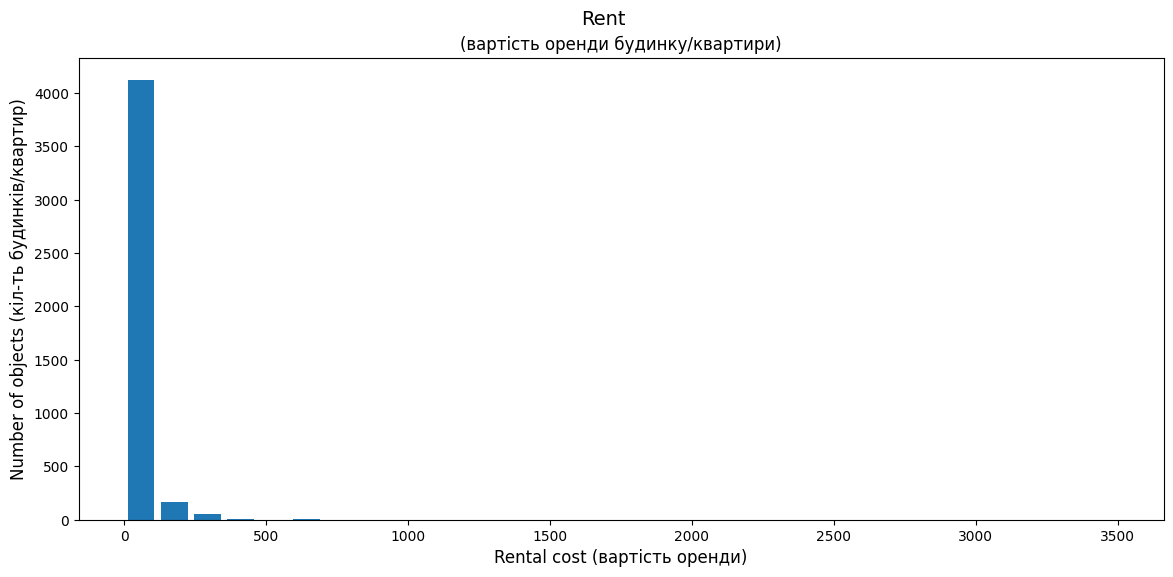

In [8]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Rent']/1000).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Rent', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(вартість оренди будинку/квартири)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Rental cost (вартість оренди)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

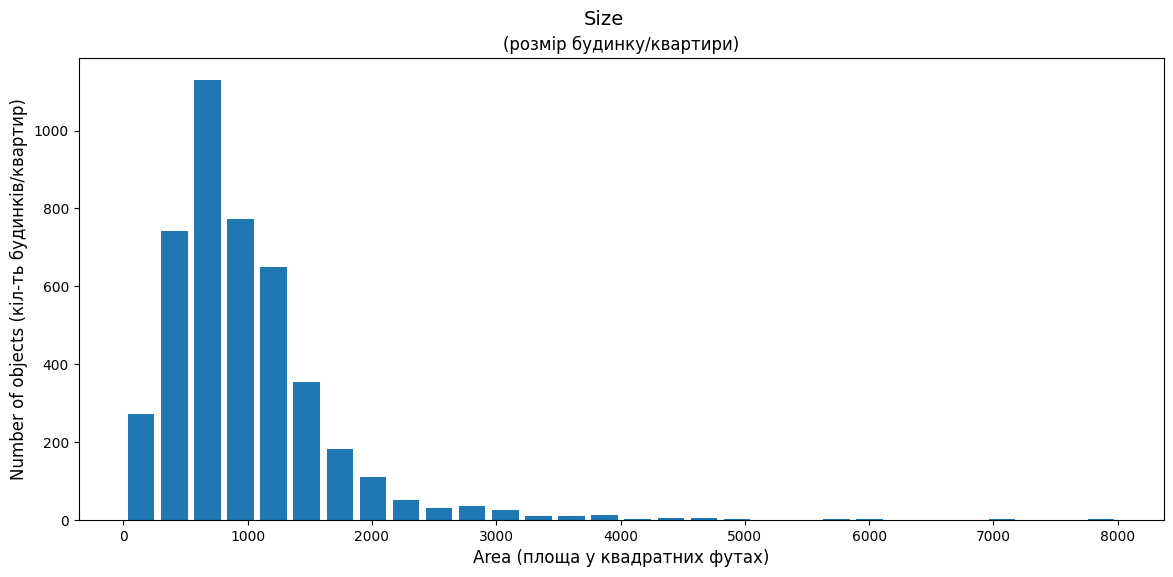

In [9]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Size']).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Size', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(розмір будинку/квартири)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Area (площа у квадратних футах)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

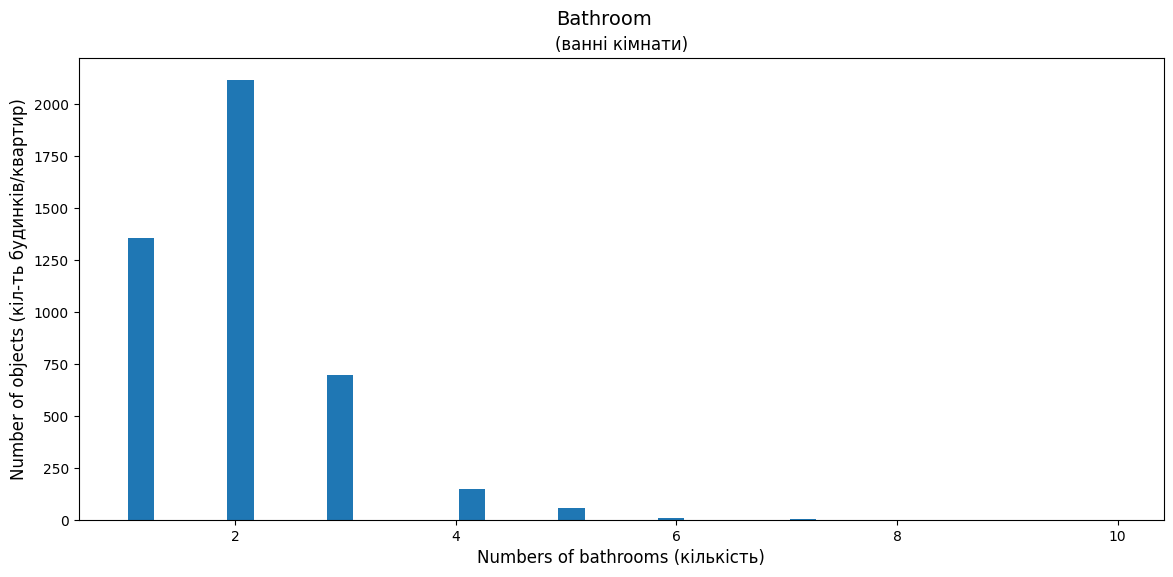

In [10]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Bathroom']).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Bathroom', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(ванні кімнати)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Numbers of bathrooms (кількість)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

Ящики з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

Text(0.5, 0, 'BHK (кількість кімнат)')

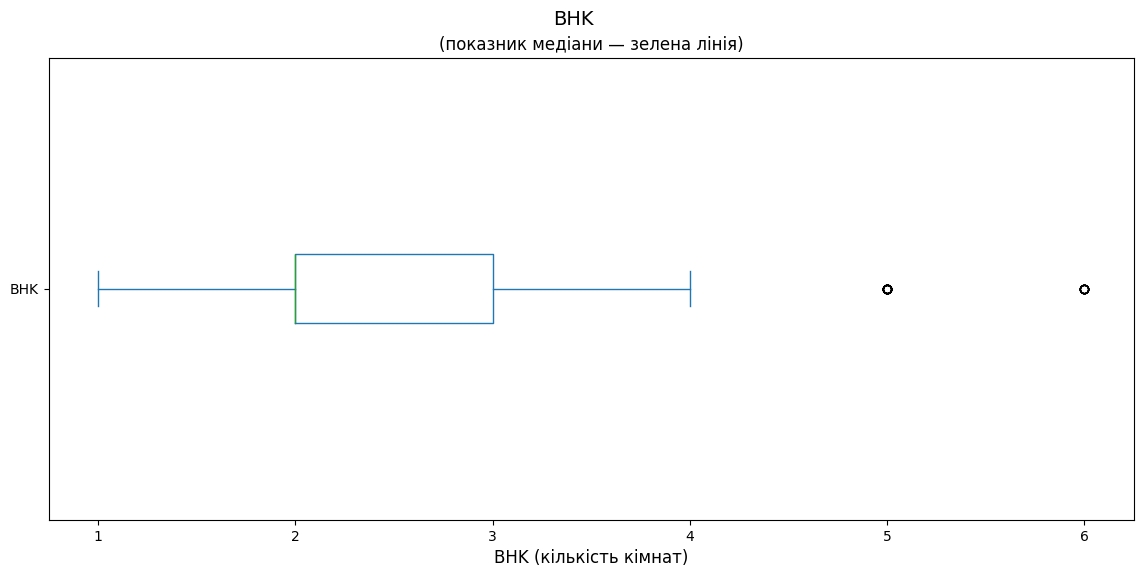

In [11]:
# малюємо ящик з вусами BHK(кількість спалень, вітальня та кухня)
ax = df['BHK'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('BHK', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('BHK (кількість кімнат)', fontsize=12)

In [12]:
# робимо корегування/видалення викидів
mask = df['Rent'] < 0.5 * 1e6
mask.sum()

np.int64(4359)

In [13]:
# записуємо у змінну відфільтрованих даних
df_filter = df[mask]

Text(0.5, 0, 'Rental cost (вартість оренди)')

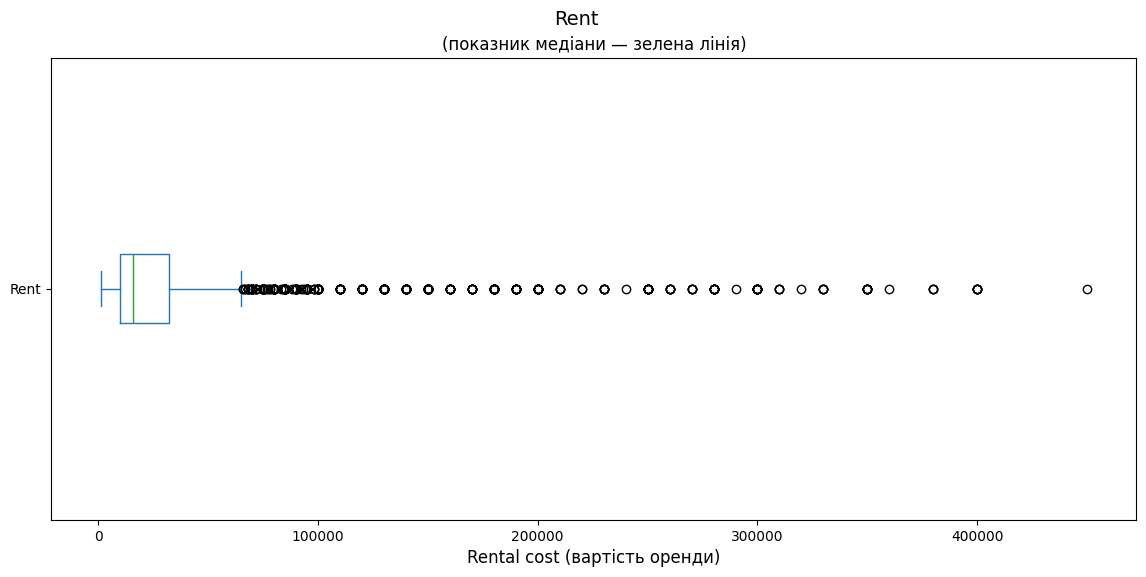

In [14]:
# малюємо ящик з вусами Rent(вартість оренди)
ax = df_filter['Rent'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Rent', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Rental cost (вартість оренди)', fontsize=12)

In [15]:
# робимо корегування/видалення викидів
mask = df['Size'] < 5000
mask.sum()

np.int64(4397)

In [16]:
# записуємо у змінну відфільтрованих даних
df_filter = df[mask]

Text(0.5, 0, 'Area (площа у квадратних футах)')

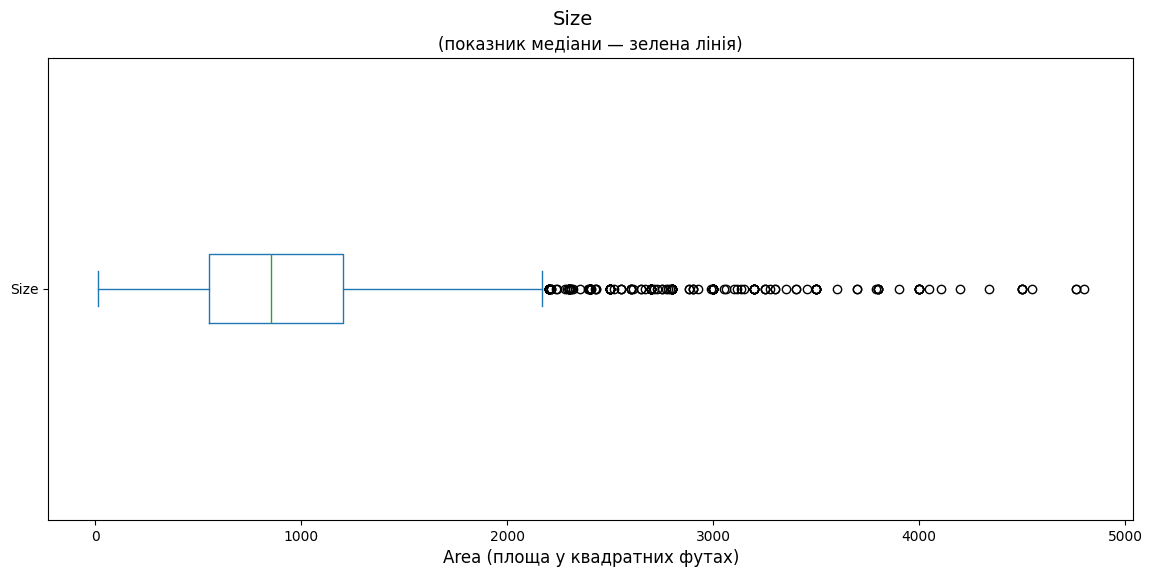

In [17]:
# малюємо ящик з вусами Size(площа)
ax = df_filter['Size'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Size', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Area (площа у квадратних футах)', fontsize=12)

Text(0.5, 0, 'Numbers of bathrooms (кількість)')

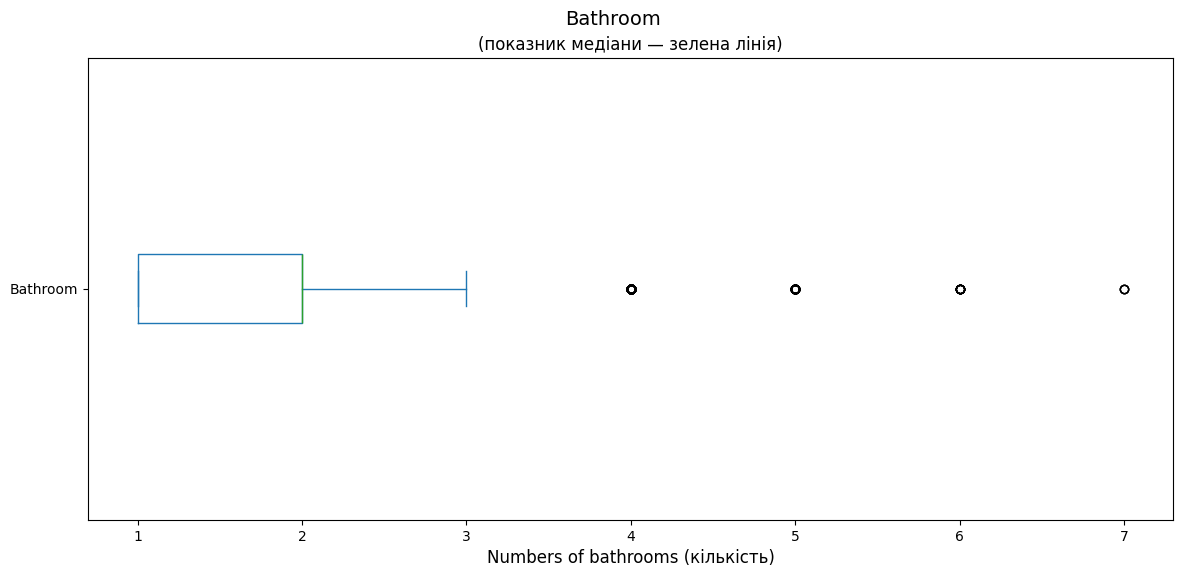

In [18]:
# малюємо ящик з вусами Bathroom(кількість ванних кімнат)
ax = df_filter['Bathroom'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Bathroom', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Numbers of bathrooms (кількість)', fontsize=12)

Отримуємо ознаки та цільову змінну(X, y)

In [19]:
y = df['Rent']
X = df.drop(columns='Rent')
X

,Posted On,BHK,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,NaN,1000.0,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2.0,Contact Owner
4742,2022-05-15,3.0,2000.0,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Owner
4743,2022-07-10,3.0,1750.0,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3.0,Contact Agent
4744,2022-07-06,3.0,1500.0,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2.0,Contact Agent


In [20]:
y

,Rent
0,10000.0
1,20000.0
2,17000.0
3,10000.0
4,7500.0
...,...
4741,15000.0
4742,29000.0
4743,35000.0
4744,45000.0


У стовпчику **Rent** є **377** пропущених значень (*NaN*). Якщо в ознаках '**X**' пропуски легко заповнюються через пайплайн (SimpleImputer), то в цільовій змінній '**y**' пропуски залишати не можна, оскільки модель не може навчатися на об'єктах, де невідома відповідь.
 ОТЖЕ, перед розділенням даних на ТРЕНУВАЛЬНІ та ТЕСТОВІ у функію train_test_split: потрібно видалити рядки з пропущеними значеннями, тобто де **Rent** дорівнює *NaN*

In [24]:
# Видаляємо рядки, де цільова змінна Rent є NaN
df = df.dropna(subset=['Rent'])

In [25]:
# Після виділяємо X та y
y = df['Rent']
X = df.drop(columns='Rent')

# Розділюємо дані на тренувальні та тестові

In [26]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Розподіл даних на тренувальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% даних іде на тест, 80% на тренування
    random_state=42,    # Фіксація випадкового стану для відтворюваності
    )
# -де ' train_test_split ' - назва функції

In [27]:
X_train.shape

(3495, 11)

In [28]:
X_test.shape

(874, 11)

In [29]:
y_train.shape

(3495,)

In [30]:
y_test.shape

(874,)

# Завдання 2
Створіть Pipeline для обробки даних числових та категоріальних даних

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Визначення числових та категоріальних колонок
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object', 'category']).columns

# Пайплайн для числових даних
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Пайплайн для категоріальних даних
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# Об'єднання в один препроцесор
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Застосування до тренувальних та тестових даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

* *Вивід ЧИСЛОВИХ СТОВПЧИКІВ 'num_features' для ознайомлення*

In [32]:
num_features

Index(['BHK', 'Size', 'Bathroom'], dtype='object')

* *Вивід СТОВПЧИКІВ із 'str' рядками -"num_features" для ознайомлення*

In [33]:
cat_features

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object')

* *Вивід 'preprocessor' (об'єднання num_pipeline & cat_pipeline) на екран для ознайомлення*

In [34]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])

# Завдання 3
Об'єднайте препроцесор з деревом рішень в один пайплайн

Об'єднуємо препроцесор та модель дерева рішень у єдиний фінальний пайплайн.
Для цього використовується клас **Pipeline** з **sklearn.pipeline**

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# 1. Створюємо модель дерева рішень для регресії
tree_model = DecisionTreeRegressor(
    max_depth=7,          # Обмеження глибини дерева (щоб уникнути перенавчання)
    min_samples_leaf=5,   # Мінімальна кількість об'єктів у листі
    random_state=42       # Фіксація випадковості
)

# 2. Об'єднуємо preprocessor та tree_model в один підсумковий Pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Наш препроцесор із Завдання 2
    ('model', tree_model)           # Модель дерева
])

# 3. Навчаємо увесь пайплайн на сирих тренувальних даних (X_train, y_train)
final_pipeline.fit(X_train, y_train)

print("Фінальний пайплайн успішно створено та навчено!")

Фінальний пайплайн успішно створено та навчено!


# Завдання 4
Виведіть основні метрики моделі

* ***MAE (Mean Absolute Error — Середня абсолютна помилка)***
  Що вимірює: Середнє значення відхилення прогнозованої ціни від реальної.
  Як розуміти результат: Якщо, наприклад, MAE = 2.50$, це означає, що модель у середньому помиляється на 2.50 одиниці (тисяч доларів, гривень тощо) у будь-який бік — як у більший, так і в менший.
* *MSE (Mean Squared Error — Середня квадратична помилка)*
  Що вимірює: Середнє  значення квадратів усіх помилок.
  Як розуміти результат: Оскільки помилка підноситься до квадрата, ця метрика дуже сильно покарання (штрафує) модель за великі промахи.
  **Якщо модель помилилася на 2 штраф буде 4, а якщо на 10 штраф стане 100.**
* *RMSE (Root Mean Squared Error — Корінь із середньої квадратичної помилки)*
  Що вимірює: Квадратний корінь із MSE. Як розуміти результат: Повертає значення метрики назад у звичайні одиниці вимірювання ціни (як і MAE). Порівняння з MAE: Якщо RMSE дуже близький до MAE, модель помиляється рівномірно.Якщо RMSE значно більший за MAE, це сигнал, що у даних є поодинокі дуже великі помилки (викиди), де дерево сильно схибило.
* *R² Score (Коефіцієнт детермінації) *
  Що вимірює: Якість моделі у відсотках/частках порівняно з простою підказкою «брати завжди середню ціну».
  Як розуміти результат:
  1.0 ідеальна модель прогнозує абсолютну точність без помилок
 (85%) — відмінний результат. Модель пояснює 85% закономірностей у цінах.
  0.0 модель працює так само як якщо б ти просто видавав середнє арифметичне значення ціни для всіх об'єктів.
  Меньше — модель працює гірше за випадкове вгадування.*

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Отримуємо прогнози для тестової вибірки
y_pred = final_pipeline.predict(X_test)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_test, y_pred)

# 3. Виводимо результати
print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ ===")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error):  {mse:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R² Score:                   {r2:.4f}")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ ===
MAE  (Mean Absolute Error): 15232.4838
MSE  (Mean Squared Error):  1417408883.8236
RMSE (Root MSE):            37648.4911
R² Score:                   0.5020


# Завдання 5
Змініть параметри моделі та попробуйте покращити результат та натренуйте його

# Завдання 6
Спрогнозуйте ціну оренди на тестових даних та порівняйте зі справжніми